In [62]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np



In [63]:
train_datagen = ImageDataGenerator(
    validation_split=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

training_set = train_datagen.flow_from_directory(
    '../data/chest_xray/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True
)


Found 4173 images belonging to 2 classes.


In [64]:
validation_datagen = ImageDataGenerator(
    validation_split=0.2
)

validation_set = validation_datagen.flow_from_directory(
    '../data/chest_xray/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 1043 images belonging to 2 classes.


In [65]:
test_datagen = ImageDataGenerator()

test_set = test_datagen.flow_from_directory(
    '../data/chest_xray/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [66]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(training_set.classes),
    y=training_set.classes
)

class_weights = dict(enumerate(class_weights_array))

print("Class indices:", training_set.class_indices)
print("Class weights:", class_weights)

Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Class weights: {0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}


In [67]:
cnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,416 (15.46 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 2,564 (10.02 KB)

In [68]:
images, labels = next(training_set)

print("Image shape:", images.shape)
print("Minimum:", images.min())
print("Maximum:", images.max())
print("Mean:", images.mean())
print("Labels:", np.unique(labels, return_counts=True))

Image shape: (32, 224, 224, 3)
Minimum: 0.0
Maximum: 255.0
Mean: 121.06978
Labels: (array([0., 1.], dtype=float32), array([11, 21]))


In [69]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [70]:
cnn = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [71]:
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [72]:
training_set.reset()
validation_set.reset()
test_set.reset()

In [73]:
history = cnn.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 74s 528ms/step - accuracy: 0.6065 - loss: 0.6656 - val_accuracy: 0.8504 - val_loss: 0.5480
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 71s 540ms/step - accuracy: 0.7254 - loss: 0.5569 - val_accuracy: 0.8984 - val_loss: 0.4541
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 66s 502ms/step - accuracy: 0.7980 - loss: 0.4793 - val_accuracy: 0.8811 - val_loss: 0.4200
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 66s 501ms/step - accuracy: 0.8248 - loss: 0.4270 - val_accuracy: 0.8917 - val_loss: 0.3734
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 66s 501ms/step - accuracy: 0.8394 - loss: 0.3954 - val_accuracy: 0.8686 - val_loss: 0.3657
Epoch 6/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 66s 503ms/step - accuracy: 0.8450 - loss: 0.3768 - val_accuracy: 0.8696 - val_loss: 0.3503
Epoch 7/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 67s 510ms/step - accuracy: 0.8526 - loss: 0.3548 - val_accuracy: 0.8696 - val_loss: 0.3358
Epoch 8/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 67s 508ms/step - accuracy: 0.8617 - loss: 0

In [74]:
test_loss, test_accuracy = cnn.evaluate(test_set)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 548ms/step - accuracy: 0.8205 - loss: 0.3612
Test Loss: 0.3611794412136078
Test Accuracy: 0.8205128312110901


In [75]:
from sklearn.metrics import confusion_matrix
import numpy as np

test_set.reset()

y_pred_prob = cnn.predict(test_set)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

y_true = test_set.classes

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 380ms/step
Confusion Matrix:
[[162  72]
 [ 40 350]]


In [76]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=['NORMAL', 'PNEUMONIA']
))

              precision    recall  f1-score   support

      NORMAL       0.80      0.69      0.74       234
   PNEUMONIA       0.83      0.90      0.86       390

    accuracy                           0.82       624
   macro avg       0.82      0.79      0.80       624
weighted avg       0.82      0.82      0.82       624



In [77]:
cnn.save('../models/pneumonia_efficientnet.keras')

In [78]:
import os

print(os.path.exists('../models/pneumonia_efficientnet.keras'))

True


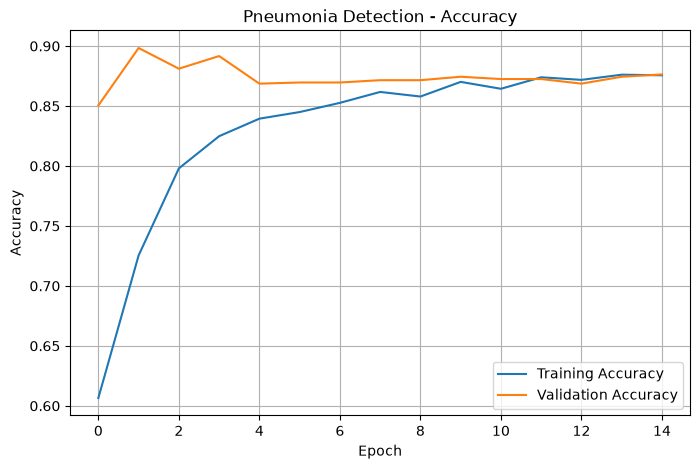

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Pneumonia Detection - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

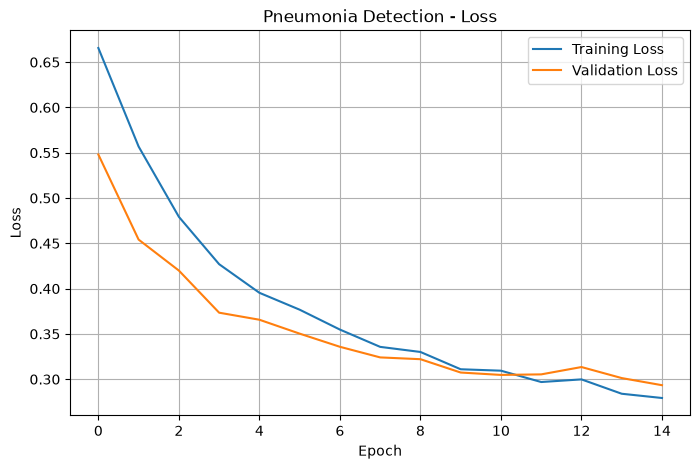

In [80]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Pneumonia Detection - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()